# Llama with LoRA

This notebook uses an off the shelf Llama model slightly trained with LoRa to classify a news article into one of five bias labels. We freeze Llama and add a classification head to create a baseline Llama implementation before going on to LoRA in the next notebook. 

In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader      

from transformers import AutoTokenizer

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler


import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.llama_lora import LlamaClassifier

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ]
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['base']


Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 8
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(LlamaClassifier, model_id=model_id, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)


In [6]:
print('Training base dataset net')
net.fit(train, torch.tensor(train.labels))

Training base dataset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr       dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  --------
      1       0.1431      0.1048        1.6409       0.1514      0.1176        1.6564  0.0000  139.8936
      2       0.1567      0.1273        1.6287       0.1829      0.1556        1.6327  0.0000  140.3941
      3       0.2089      0.2193        1.5947       0.2714      0.2890        1.5989  0.0000  140.4814
      4       0.3212      0.3505        1.5578       0.3829      0.4021        1.5733  0.0000  140.4849
      5       0.4099      0.4259        1.5223       0.4371      0.4470        1.5413  0.0000  140.5388
      6       0.4700      0.4825        1.4685       0.4714      0.4820        1.4772  0.0000  140.5368
      7       0.5072      0.5241        1.3769       0.4857      0.5029        1.3770  0.0000  140.5697
      8       0.5465      0.5662      

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LlamaClassifier(
    (llama): PeftModelForSequenceClassification(
      (base_model): LoraModel(
        (model): LlamaModel(
          (embed_tokens): Embedding(32000, 2048)
          (layers): ModuleList(
            (0-21): 22 x LlamaDecoderLayer(
              (self_attn): LlamaAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=256, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=256, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
                (o_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                  (lora_magnitude_vector): ModuleDict()
                )
              )
              (mlp): LlamaMLP(
                (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
                (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
                (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
                (act_fn): SiLU()
              )
              (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
              (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
            )
          )
          (norm): LlamaRMSNorm((2048,), eps=1e-05)
          (rotary_emb): LlamaRotaryEmbedding()
        )
      )
    )
    (classifier): Linear(in_features=2048, out_features=5, bias=True)
  ),
)

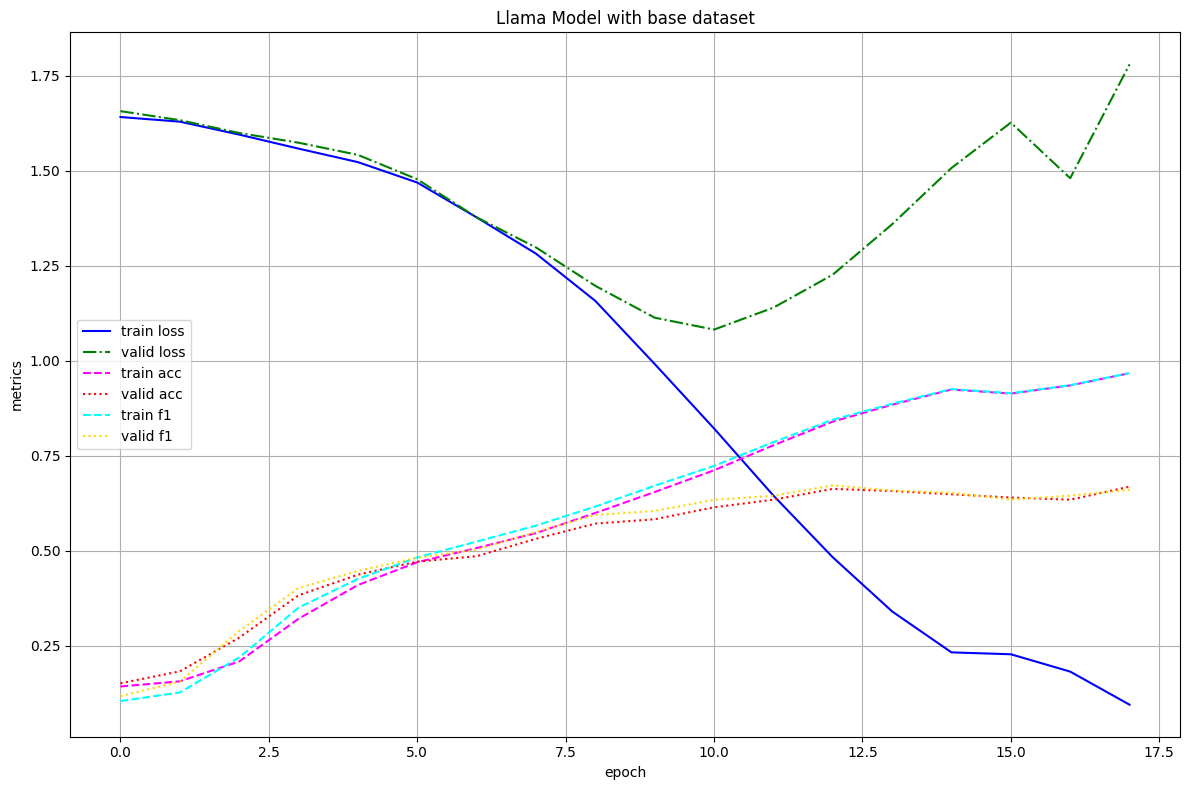

In [7]:
from utils import plot_result_curves

# Call this with the best BERT model found
plot_result_curves(net, 'Llama Model with base dataset');

# Evaluation

Building on our previous TinyLlama findings we tried fine tuning with LoRA, which we expect to help our model converge faster and increase performance. 

The reason we chose LoRA was its efficiency on compute and lower requirements compared to other fine tuning methods - studies found LoRA significantly improves model performance compared to fine-tuning only the classifier head, achieving state-of-the-art results on both simple and complex classification tasks while requiring fewer data samples. (Dausort et al. 2024)

The LoRA implementation found an optimal weighted f1 score at epoch 13 compared to epoch 22 in the base TinyLlama implementation. It was also able to achieve a higher performance.

We do see some signs of overfitting however, though the performance numbers for both accuracy and weighted f1 looks promising

Dausort, M., Godelaine, T., Zanella, M., Khoury, K.E., Salmon, I. and Macq, B., 2024. Exploring Foundation Models Fine-Tuning for Cytology Classification. arXiv preprint arXiv:2411.14975.

In [8]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [9]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'Llama-lora Base Dataset')

Llama-lora Base Dataset Accuracy: 64.76%
Llama-lora Base Dataset Weighted F1-score: 0.6369

Classification Report:
               precision    recall  f1-score   support

      center     0.4000    0.1951    0.2623        41
   lean left     0.5323    0.5410    0.5366        61
  lean right     0.2692    0.3784    0.3146        37
        left     0.7579    0.8604    0.8059       222
       right     0.7255    0.4868    0.5827        76

    accuracy                         0.6476       437
   macro avg     0.5370    0.4923    0.5004       437
weighted avg     0.6458    0.6476    0.6369       437



# Classification report summary

The optimized TinyLlama model resulted in a weighted f1 score at 0.6369 and accuracy of 64.76%. This puts the model just behind of FFNN TD-IDF in our comparison.

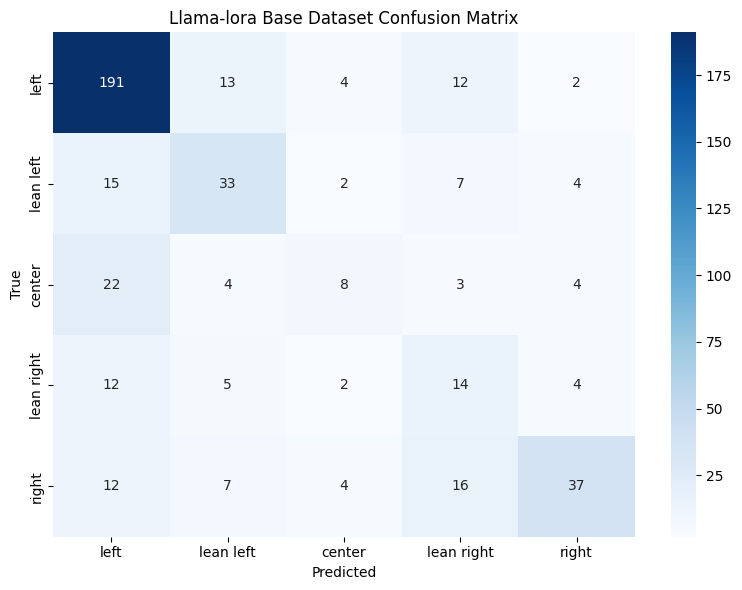

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'Llama-lora Base Dataset');

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for Llama-lora Base Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for Llama-lora Base Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[384  12]
 [ 33   8]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[347  29]
 [ 28  33]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[362  38]
 [ 23  14]]

One-vs-Rest Confusion Matrix for class 'left':
[[154  61]
 [ 31 191]]

One-vs-Rest Confusion Matrix for class 'right':
[[347  14]
 [ 39  37]]


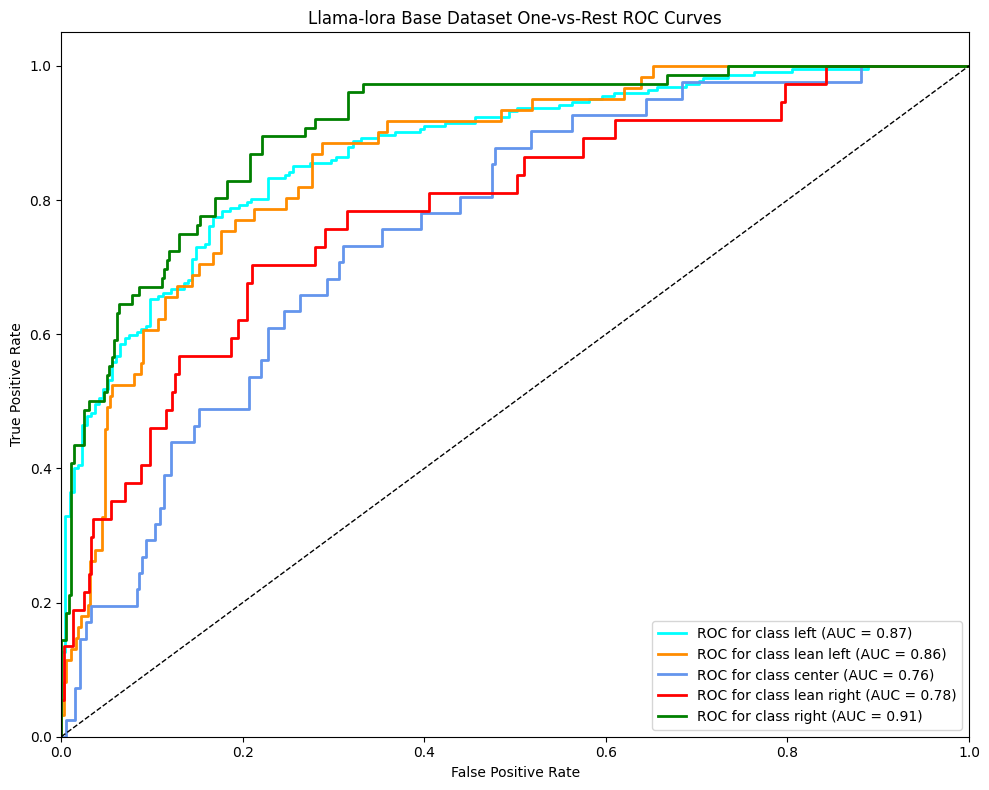

In [12]:
from utils import plot_roc


plot_roc(y_prob, net, test, classes, 'Llama-lora Base Dataset');

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| Decision Tree    | 59.27    | 60.29       |
| FFNN (TD-IDF)    | 69.79    | 68.85       |
| FFNN (GloVe)     | 32.27    | 33.72       |
| LSTM             | 37.76    | 41.46       |
| BERT             | 60.41    | 61.04       |
| TinyLlama        | 51.72    | 53.75       |
| TinyLlama (LoRA) | 64.76    | 63.69       |

### Final Remarks

LoRA significatntly boosted the performance of the original TinyLlama model and had performance just shy of the FFNN TD-IDF implementation. The trade off however, is significantly more compute and time needed to train the model.